Core libraries imported.
Project directories ready.
Environment loaded. Model tiers:
  WEAK   -> gpt-4o-mini
  MID    -> gpt-5.4-mini
  STRONG -> gpt-5.4
Conditions: ['C1', 'C2', 'C3', 'C4', 'C5']
Datasets   : ['D1', 'D2', 'D2_fin', 'D3']
Grayscale plotting style configured.
Condition styles: {'C1': '0.15', 'C2': '0.3', 'C3': '0.45', 'C4': '0.6', 'C5': '0.75'}
Live check skipped (set RUN_LIVE_CHECK=True to test credentials).
Setup complete. Config snapshot saved.
Loaded full results: n=32598 rows.
Conditions present: ['C1', 'C2', 'C3', 'C4', 'C5_L1', 'C5_L2', 'C5_L3']
Models present    : ['MID', 'STRONG', 'WEAK']
Datasets present  : ['D1', 'D2', 'D2_fin']
RQ1 rows: 18408 total, 18384 EX-scoreable.


,dataset,model_tier,condition,n,EX,valid,tbl_recall,col_prec_strict
0,D1,MID,C1,1034,0.7573,1.0000,1.0000,0.1562
1,D1,MID,C2,1034,0.7495,1.0000,1.0000,0.1641
2,D1,MID,C3,1034,0.7215,1.0000,0.9521,0.1842
3,D1,MID,C4,1034,0.7611,1.0000,1.0000,0.1624
4,D1,STRONG,C1,1034,0.7785,0.9990,1.0000,0.1562
5,D1,STRONG,C2,1034,0.7785,1.0000,1.0000,0.1641
6,D1,STRONG,C3,1034,0.7427,0.9990,0.9521,0.1842
7,D1,STRONG,C4,1034,0.7776,0.9990,1.0000,0.1624
8,D1,WEAK,C1,1034,0.7466,0.9981,1.0000,0.1562
9,D1,WEAK,C2,1034,0.7311,0.9981,1.0000,0.1641


Saved table: 03_rq1_ex_table.csv, 03_rq1_ex_table.tex


,dataset,model_tier,condition,exec_match,delta_exec_match
1,D1,MID,C2,0.7495,-0.0077
2,D1,MID,C3,0.7215,-0.0358
3,D1,MID,C4,0.7611,0.0039
5,D1,STRONG,C2,0.7785,0.0000
6,D1,STRONG,C3,0.7427,-0.0358
7,D1,STRONG,C4,0.7776,-0.0010
9,D1,WEAK,C2,0.7311,-0.0155
10,D1,WEAK,C3,0.7060,-0.0406
11,D1,WEAK,C4,0.7437,-0.0029
13,D2,MID,C2,0.4398,-0.0783


,dataset,model_tier,n_pairs,C1_only_correct,C4_only_correct,EX_C1,EX_C4,delta_EX,p_value
0,D1,MID,1034,5,9,0.7573,0.7611,0.0039,0.4240
1,D1,STRONG,1034,6,5,0.7785,0.7776,-0.0010,1.0000
2,D1,WEAK,1034,8,5,0.7466,0.7437,-0.0029,0.5811
3,D2,MID,498,18,9,0.5181,0.5000,-0.0181,0.1221
4,D2,STRONG,498,8,10,0.5281,0.5321,0.0040,0.8145
5,D2,WEAK,498,14,14,0.4438,0.4438,0.0000,1.0000


Saved table: 03_rq1_significance.csv, 03_rq1_significance.tex
Saved figure: 03_rq1_ex_by_condition.png, 03_rq1_ex_by_condition.pdf


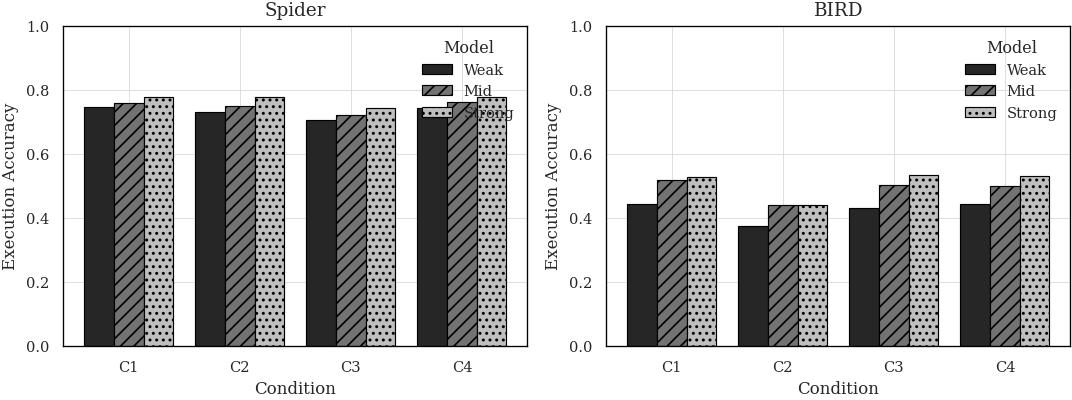

D1/MID: C4 vs C1 improves (dEX=+0.004, p=0.424, n=1034).
D1/STRONG: C4 vs C1 regresses (dEX=-0.001, p=1.000, n=1034).
D1/WEAK: C4 vs C1 regresses (dEX=-0.003, p=0.581, n=1034).
D2/MID: C4 vs C1 regresses (dEX=-0.018, p=0.122, n=498).
D2/STRONG: C4 vs C1 improves (dEX=+0.004, p=0.815, n=498).
D2/WEAK: C4 vs C1 no gain (dEX=+0.000, p=1.000, n=498).


In [1]:
# ============================================================================
# 03_rq1_accuracy.ipynb
# ----------------------------------------------------------------------------
# Beyond Full-Schema Prompting: A Graph-based Semantic Layer for Text-to-SQL
#
# RQ1: Does the graph-based semantic layer improve SQL accuracy over full-schema
#      prompting? Compares Execution Accuracy (EX) and validity across conditions
#      C1 (Full) vs C2/C3/C4, with per-condition schema-linking context.
#
# Consumes : results/tables/generation_results.csv  (from notebook 02, full run)
#            falls back to *_smoke.csv if the full file is absent.
# Produces : results/figures/03_rq1_ex_by_condition.{png,pdf}
#            results/tables/03_rq1_ex_table.{csv,tex}
#            results/tables/03_rq1_significance.{csv,tex}
#
# Anonymity: no filesystem paths are printed.
# ============================================================================


# %% [markdown]
# ## Cell 1 - Load configuration + master results

# %%
%run 00_setup_and_config.ipynb


# %%
from scipy import stats

def load_results():
    """Load the full master results, else the smoke file, else raise."""
    full = TABLES_DIR / "generation_results.csv"
    smoke = TABLES_DIR / "generation_results_smoke.csv"
    if full.exists():
        df = pd.read_csv(full)
        print(f"Loaded full results: n={len(df)} rows.")
    elif smoke.exists():
        df = pd.read_csv(smoke)
        print(f"[warning] full results not found; using SMOKE data (n={len(df)}). "
              f"Figures are placeholders until notebook 02 full run completes.")
    else:
        raise FileNotFoundError("Run notebook 02 first to produce generation_results.")
    return df

res = load_results()
print("Conditions present:", sorted(res["condition"].unique()))
print("Models present    :", sorted(res["model_tier"].unique()))
print("Datasets present  :", sorted(res["dataset"].unique()))


# %% [markdown]
# ## Cell 2 - RQ1 scope
# RQ1 focuses on the accuracy gain from selective schema linking. We compare the
# baseline C1 against retrieval conditions on the primary datasets, per model.
# EX rows with NaN (DB missing at scoring time) are excluded from EX means.

# %%
RQ1_CONDITIONS = ["C1", "C2", "C3", "C4"]
RQ1_DATASETS = ["D1", "D2"]        # BIRD contributes once its DBs are placed

rq1 = res[res["condition"].isin(RQ1_CONDITIONS) &
          res["dataset"].isin(RQ1_DATASETS)].copy()

# Keep only rows that could be EX-scored (exec_match not NaN) for accuracy stats.
rq1_ex = rq1.dropna(subset=["exec_match"]).copy()
print(f"RQ1 rows: {len(rq1)} total, {len(rq1_ex)} EX-scoreable.")


# %% [markdown]
# ## Cell 3 - EX / validity table by dataset x condition x model

# %%
def agg_metrics(df):
    return (df.groupby(["dataset", "model_tier", "condition"])
              .agg(n=("qid", "count"),
                   EX=("exec_match", "mean"),
                   valid=("valid_sql", "mean"),
                   tbl_recall=("table_recall", "mean"),
                   col_prec_strict=("col_precision_strict", "mean"))
              .reset_index())

rq1_table = agg_metrics(rq1_ex)
rq1_table[["EX", "valid", "tbl_recall", "col_prec_strict"]] = \
    rq1_table[["EX", "valid", "tbl_recall", "col_prec_strict"]].round(4)
display(rq1_table)
save_table(rq1_table, "03_rq1_ex_table")


# %% [markdown]
# ## Cell 4 - Delta-EX vs the C1 baseline
# Positive values mean the retrieval condition beats full-schema prompting.

# %%
def delta_vs_baseline(df, baseline="C1", metric="exec_match"):
    base = (df[df["condition"] == baseline]
            .groupby(["dataset", "model_tier"])[metric].mean())
    rows = []
    for (ds, mt, cond), g in df.groupby(["dataset", "model_tier", "condition"]):
        b = base.get((ds, mt), np.nan)
        rows.append({"dataset": ds, "model_tier": mt, "condition": cond,
                     metric: g[metric].mean(),
                     f"delta_{metric}": g[metric].mean() - b})
    return pd.DataFrame(rows)

rq1_delta = delta_vs_baseline(rq1_ex)
rq1_delta = rq1_delta[rq1_delta["condition"] != "C1"]
rq1_delta[["exec_match", "delta_exec_match"]] = \
    rq1_delta[["exec_match", "delta_exec_match"]].round(4)
display(rq1_delta.sort_values(["dataset", "model_tier", "condition"]))


# %% [markdown]
# ## Cell 5 - Significance: C4 (Hybrid) vs C1 (Full), paired by question
# McNemar-style paired test on per-question EX (0/1) for each dataset x model.
# Uses the exact binomial on discordant pairs (robust for small n).

# %%
def paired_c4_vs_c1(df):
    rows = []
    for (ds, mt), g in df.groupby(["dataset", "model_tier"]):
        piv = g.pivot_table(index="qid", columns="condition",
                            values="exec_match", aggfunc="first")
        if not {"C1", "C4"}.issubset(piv.columns):
            continue
        pair = piv[["C1", "C4"]].dropna()
        if len(pair) == 0:
            continue
        c1, c4 = pair["C1"].astype(int), pair["C4"].astype(int)
        b = int(((c1 == 1) & (c4 == 0)).sum())   # C1 right, C4 wrong
        c = int(((c1 == 0) & (c4 == 1)).sum())   # C1 wrong, C4 right
        n_disc = b + c
        # exact binomial p-value (two-sided) on discordant pairs
        if n_disc > 0:
            p = stats.binomtest(min(b, c), n_disc, 0.5,
                                alternative="two-sided").pvalue
        else:
            p = np.nan
        rows.append({"dataset": ds, "model_tier": mt, "n_pairs": len(pair),
                     "C1_only_correct": b, "C4_only_correct": c,
                     "EX_C1": c1.mean(), "EX_C4": c4.mean(),
                     "delta_EX": c4.mean() - c1.mean(), "p_value": p})
    return pd.DataFrame(rows)

rq1_sig = paired_c4_vs_c1(rq1_ex)
if len(rq1_sig):
    rq1_sig[["EX_C1", "EX_C4", "delta_EX", "p_value"]] = \
        rq1_sig[["EX_C1", "EX_C4", "delta_EX", "p_value"]].round(4)
    display(rq1_sig)
    save_table(rq1_sig, "03_rq1_significance")
else:
    print("Not enough paired C1/C4 data yet (need the full run).")


# %% [markdown]
# ## Cell 6 - Figure: EX by condition (grayscale, grouped by model)
# One panel per dataset; bars per condition, grouped by model tier. Grayscale
# with hatches so conditions stay distinct in B/W. dpi 600, png+pdf, no caption.

# %%
def plot_ex_by_condition(df, datasets):
    datasets = [d for d in datasets if d in df["dataset"].unique()]
    if not datasets:
        print("No datasets to plot yet.")
        return
    fig, axes = plt.subplots(1, len(datasets),
                             figsize=(4.6 * len(datasets), 3.6), squeeze=False)
    for ax, ds in zip(axes[0], datasets):
        sub = df[df["dataset"] == ds]
        conds = [c for c in RQ1_CONDITIONS if c in sub["condition"].unique()]
        tiers = [t for t in MODEL_TIER_ORDER if t in sub["model_tier"].unique()]
        x = np.arange(len(conds))
        w = 0.8 / max(1, len(tiers))
        for i, mt in enumerate(tiers):
            vals = [sub[(sub["condition"] == c) & (sub["model_tier"] == mt)]
                    ["exec_match"].mean() for c in conds]
            gray = gray_palette(len(tiers))[i]
            bars = ax.bar(x + i * w, vals, width=w, color=gray,
                          edgecolor="black", linewidth=0.7,
                          label=MODEL_TIER_LABELS.get(mt, mt))
            for b in bars:
                b.set_hatch(HATCHES[i % len(HATCHES)])
        ax.set_xticks(x + w * (len(tiers) - 1) / 2)
        ax.set_xticklabels(conds)
        ax.set_ylim(0, 1.0)
        ax.set_xlabel("Condition")
        ax.set_ylabel("Execution Accuracy")
        ax.set_title(DATASETS.get(ds, ds))
        ax.legend(title="Model")
    save_figure(fig, "03_rq1_ex_by_condition")
    plt.show()

plot_ex_by_condition(rq1_ex, RQ1_DATASETS)


# %% [markdown]
# ## Cell 7 - Takeaways (printed, no paths)
# Summarizes whether Hybrid (C4) beats Full (C1) on average, per dataset.

# %%
if len(rq1_sig):
    for _, r in rq1_sig.iterrows():
        verdict = ("improves" if r["delta_EX"] > 0 else
                   "no gain" if r["delta_EX"] == 0 else "regresses")
        sig = ("" if np.isnan(r["p_value"])
               else f", p={r['p_value']:.3f}")
        print(f"{r['dataset']}/{r['model_tier']}: C4 vs C1 {verdict} "
              f"(dEX={r['delta_EX']:+.3f}{sig}, n={int(r['n_pairs'])}).")
else:
    print("Run notebook 02 (full) to populate RQ1 significance.")